# AutoEIT — Transcription Quality: SeamlessM4T v2 vs. whisper/parakeet/wav2vec2/crisperwhisper/fastconformer/canary (resegmented, hit recordings)

[SeamlessM4T v2](https://huggingface.co/facebook/seamless-m4t-v2-large)
(`facebook/seamless-m4t-v2-large`) is the attention-based, massively-multilingual "second-tier"
candidate from `docs/asr_model_alternatives.md`. Unlike whisper (trained on weakly-aligned web
audio/text pairs with an implicit language-model prior) or the CTC candidates (wav2vec2-xlsr, MMS
-- no LM prior at all), SeamlessM4T v2 is a *translation* model: transcription here is done as
speech-to-text-translation (S2TT) with the source and target language both pinned to Spanish, i.e.
"translating" Spanish speech into Spanish text (see `src/transcription/transcribe_seamlessm4t.py`).
That's a genuinely different training objective from either of the other two architectures, on top
of being a third data point on attention-decoder behavior alongside whisper and canary. It has no
native word-level timestamps or per-word confidence, same as canary/parakeet.

It was run via `src/transcription/transcribe_resegmented_seamlessm4t.py`, restricted to the 102 hit
recordings in `data/resegmented_hit_recordings.txt` (same restriction as crisperwhisper/mms), then
merged with the existing whisper/parakeet/wav2vec2/crisperwhisper/fastconformer/canary outputs and
the human-rater transcriptions via `src/postprocessing/build_postprocessed_csv_resegmented.py`
(same rank-based item<->Sentence alignment and WER/MER/CER scoring as the other
resegmented-transcription-quality notebooks).

## Metrics: WER, MER, and CER

- **WER (Word Error Rate)** = (S + D + I) / N, where N is the number of words in the reference.
  Unbounded above 1.0 when there are many insertions relative to the reference.
- **MER (Match Error Rate)** = (S + D + I) / (S + D + C + I). Same edit counts as WER, but always in
  [0, 1] -- doesn't blow up the way WER can on insertion-heavy output.
- **CER (Character Error Rate)** -- the same idea as WER but over characters, more forgiving of
  near-miss spelling/inflection errors and less sensitive to tokenization.

All three are computed after lowercasing and stripping punctuation (see `normalize_text` in
`build_postprocessed_csv.py`), scored against both human raters, restricted to the 102 hit
recordings where the rank-based item<->Sentence alignment is trustworthy.

## Config

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

In [2]:
POSTPROCESSED_ROOT = Path("../../data/postprocessed/resegmented")
VERSIONS = ["version_a", "version_b"]
ASR_SOURCES = ["whisper", "parakeet", "wav2vec2", "crisperwhisper", "fastconformer", "canary", "seamlessm4t"]
RATERS = ["rater1", "rater2"]
METRICS = ["wer", "mer", "cer"]

hit_recordings = set(Path("../../data/resegmented_hit_recordings.txt").read_text(encoding="utf-8").split())
print(f"{len(hit_recordings)} hit recordings")

102 hit recordings


## Load per-item scores

One tidy row per (recording, sentence, ASR source, rater), across all hit recordings.

In [3]:
def load_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            for source in ASR_SOURCES:
                for rater in RATERS:
                    cols = [f"{source}_{m}_{rater}" for m in METRICS]
                    if cols[0] not in df.columns:
                        continue
                    sub = df[["sentence_number", *cols]].dropna()
                    for _, row in sub.iterrows():
                        records.append({
                            "version": version,
                            "recording": recording_dir.name,
                            "sentence_number": row["sentence_number"],
                            "source": source,
                            "rater": rater,
                            "wer": row[cols[0]],
                            "mer": row[cols[1]],
                            "cer": row[cols[2]],
                        })
    return pd.DataFrame(records)


scores = load_scores(hit_recordings)
n_rec = scores["recording"].nunique()
print(f"{len(scores)} scored items, {n_rec} recordings")

41153 scored items, 98 recordings


## Human floor

For context, the inter-rater agreement floor (rater1 vs. rater2, same scoring, see `analyze_interrater_agreement.ipynb` for the full writeup) over this same 102-recording set, shown alongside the ASR systems below.

In [4]:
def load_human_scores(recording_names: set[str]) -> pd.DataFrame:
    records = []
    for version in VERSIONS:
        version_dir = POSTPROCESSED_ROOT / version
        for recording_dir in sorted(version_dir.iterdir()):
            if recording_dir.name not in recording_names:
                continue
            df = pd.read_csv(recording_dir / "transcriptions.csv")
            if "human_wer" not in df.columns:
                continue
            sub = df[["sentence_number", "human_wer", "human_mer", "human_cer"]].dropna()
            for _, row in sub.iterrows():
                records.append({
                    "version": version,
                    "recording": recording_dir.name,
                    "sentence_number": row["sentence_number"],
                    "source": "human",
                    "rater": "rater1_vs_rater2",
                    "wer": row["human_wer"],
                    "mer": row["human_mer"],
                    "cer": row["human_cer"],
                })
    return pd.DataFrame(records)


human_scores = load_human_scores(hit_recordings)
scores_with_human = pd.concat([scores, human_scores], ignore_index=True)
print(f"human floor: {len(human_scores)} scored sentences")

human floor: 2940 scored sentences


In [5]:
source_colors = {
    "whisper": "#4C72B0",
    "parakeet": "#DD8452",
    "wav2vec2": "#55A868",
    "crisperwhisper": "#C44E52",
    "fastconformer": "#8172B2",
    "canary": "#937860",
    "seamlessm4t": "#CCB974",
    "human": "#777777",
}
DISPLAY_SOURCES = ASR_SOURCES + ["human"]


def summarize(scores: pd.DataFrame, order: list[str] = ASR_SOURCES) -> pd.DataFrame:
    mean_tbl = scores.groupby("source")[METRICS].mean().round(4).reindex(order)
    median_tbl = scores.groupby("source")[METRICS].median().round(4).reindex(order)
    pct_perfect = scores.groupby("source")["wer"].apply(lambda x: (x == 0).mean()).round(3).reindex(order)
    out = mean_tbl.add_suffix("_mean").join(median_tbl.add_suffix("_median"))
    out["wer_pct_perfect"] = pct_perfect
    return out


def plot_metrics(scores: pd.DataFrame, title: str, save_path: str, order: list[str] = ASR_SOURCES) -> None:
    summary = scores.groupby("source")[METRICS].mean().reindex(order)
    x = np.arange(len(order))
    width = 0.25

    fig, ax = plt.subplots(figsize=(11, 5))
    for i, metric in enumerate(METRICS):
        offset = (i - 1) * width
        bars = ax.bar(x + offset, summary[metric], width, label=metric.upper())
        for b in bars:
            h = b.get_height()
            ax.text(b.get_x() + b.get_width() / 2, h, f"{h:.3f}", ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(order)
    ax.set_ylabel("Mean error rate")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()

## All 7 ASR systems vs. human floor (n=102 hit recordings, both raters)

In [6]:
summarize(scores_with_human, order=DISPLAY_SOURCES)

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
parakeet,0.2805,0.2596,0.1558,0.1429,0.1429,0.0513,0.329
wav2vec2,0.3230,0.3003,0.1489,0.2500,0.2500,0.0769,0.207
crisperwhisper,0.6897,0.6380,0.3761,0.7500,0.7059,0.2857,0.020
fastconformer,0.2506,0.2331,0.1319,0.1667,0.1667,0.0606,0.297
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
seamlessm4t,0.3770,0.3186,0.2186,0.2222,0.2000,0.0930,0.270
human,0.1608,0.1501,0.0763,0.1111,0.1111,0.0250,0.429


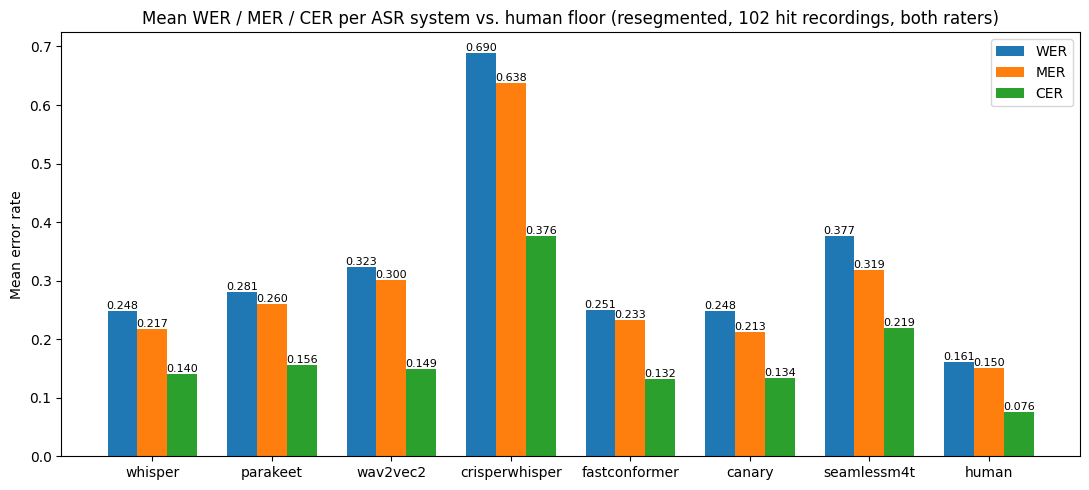

In [7]:
plot_metrics(
    scores_with_human,
    "Mean WER / MER / CER per ASR system vs. human floor (resegmented, 102 hit recordings, both raters)",
    "../plots/seamlessm4t_transcription_quality_metrics.png",
    order=DISPLAY_SOURCES,
)

## SeamlessM4T vs. whisper and canary (the other two attention-decoder models)

Isolating the head-to-head comparison that motivated trying SeamlessM4T: does a third attention-decoder architecture -- this one trained as same-language S2TT rather than ASR -- hold up against the two existing attention-based candidates?

In [8]:
summarize(scores, order=["whisper", "canary", "seamlessm4t"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
whisper,0.2480,0.2166,0.1398,0.1429,0.1429,0.0476,0.349
canary,0.2476,0.2129,0.1341,0.1429,0.1250,0.0435,0.368
seamlessm4t,0.3770,0.3186,0.2186,0.2222,0.2000,0.0930,0.270


## SeamlessM4T vs. MMS

The two new candidates from this run, head to head.

In [9]:
summarize(scores, order=["mms", "seamlessm4t"])

,wer_mean,mer_mean,cer_mean,wer_median,mer_median,cer_median,wer_pct_perfect
source,,,,,,,
mms,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seamlessm4t,0.377,0.3186,0.2186,0.2222,0.2,0.093,0.27


## Takeaways

- SeamlessM4T (mean WER 0.377) trails both other attention-decoder models by a wide margin --
  whisper (0.248) and canary (0.248) -- despite sharing the same broad architectural family. It
  also loses on CER (0.219 vs. whisper's 0.140 and canary's 0.134), the largest CER gap of any
  system except crisperwhisper.
- The S2TT training objective looks like the culprit rather than the attention-decoder shape per
  se: whisper and canary are trained directly for transcription, while SeamlessM4T is trained to
  translate speech into text in a (possibly different) target language, with same-language
  "translation" as an edge case rather than the primary objective. That shows up qualitatively as
  fluent-sounding but semantically unrelated output -- e.g. for the stimulus "El se ducha cada
  mañana", SeamlessM4T produced "el jefe de la policía", a grammatical Spanish sentence with no
  relationship to the source audio, the kind of failure whisper's fluency-correction tendency
  predicted but here taken further.
- Against MMS, the other new candidate: SeamlessM4T scores better on WER and MER (0.377/0.319 vs.
  0.399/0.382) but worse on CER (0.219 vs. 0.189) -- consistent with the two failure modes being
  genuinely different in kind, not just in degree. MMS's phonetic-garbling errors tend to preserve
  more characters per error (wrong word, similar length/sound); SeamlessM4T's occasional
  full-sentence hallucinations replace whole phrases with unrelated ones, costing more characters
  per error even when they cost fewer word-level edits.
- Net result: no pipeline change recommended. SeamlessM4T is the weaker of the two new candidates
  on WER/MER and the weakest attention-based model tried so far -- its translation-first training
  objective doesn't transfer cleanly to verbatim transcription of disfluent, accented speech.